# Proyek Praktikum Penambangan Data (UTS)
### Segmentasi Perilaku dan Profil Risiko Penjudi Daring pada Platform Crash Game Menggunakan Algoritma K-Means Clustering

**Identitas Kelompok 4:**
1. MUHAMMAD RAKAN HIBRIZI
2. JANUARSYAH AKBAR
3. Devin Sotya Prathama
4. SHINOSUKE ALEXANDER SWANDJAYA

**Mata Kuliah:** Praktikum Penambangan Data (SVPL261503)  
**Program Studi:** Sarjana Terapan (D.4) Teknologi Rekayasa Perangkat Lunak  
**Dosen Pengampu:** Dr.Eng. Ir. Ganjar Alfian, S.T., M.Eng. & Dr. Imam Fahrurrozi, S.T., M.Cs.  
**Paper Acuan:** *AI Personalization and Its Influence on Online Gamblers' Behavior* (MDPI Behavioral Sciences, 2025)  
**Dataset:** *Gambling Behavior Bustabit* (Kaggle, 50.000 transaksi)  

---

## 1. Import Library & Pengaturan Lingkungan
Mengimpor pustaka analisis data, visualisasi, dan algoritma machine learning scikit-learn.

In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 110
print('Semua library berhasil dimuat!')

Semua library berhasil dimuat!


## 2. Pemuatan Data (Data Loading)
Memuat dataset `bustabit.csv` langsung dari repositori GitHub Raw. Notebook ini dapat langsung dijalankan di Google Colab tanpa perlu mengunggah file secara manual. Jika dijalankan tanpa koneksi internet, sistem secara otomatis beralih mencari file lokal.

In [17]:
# Tautan dataset langsung dari GitHub Raw
github_raw_url = "https://raw.githubusercontent.com/januarsyah901/PPD/main/UTS/bustabit.csv"

local_candidates = [
    "bustabit.csv",
    "UTS/bustabit.csv",
    "/content/bustabit.csv",
    "../bustabit.csv"
]

try:
    print(f"Memuat dataset dari GitHub Raw: {github_raw_url}")
    df = pd.read_csv(github_raw_url)
    print("Dataset berhasil dimuat langsung dari GitHub Raw!")
except Exception as err:
    print(f"Gagal memuat dari GitHub ({err}), mencoba membaca dari direktori lokal...")
    local_path = next((p for p in local_candidates if os.path.exists(p)), None)
    if local_path is None:
        raise FileNotFoundError("Dataset tidak ditemukan baik di GitHub maupun penyimpanan lokal!")
    df = pd.read_csv(local_path)
    print(f"Dataset berhasil dimuat dari lokal: {local_path}")

print(f"Dimensi data: {df.shape[0]:,} baris dan {df.shape[1]} kolom")
df.head()

Memuat dataset dari GitHub Raw: https://raw.githubusercontent.com/januarsyah901/PPD/main/UTS/bustabit.csv
Dataset berhasil dimuat langsung dari GitHub Raw!
Dimensi data: 50,000 baris dan 9 kolom


,Id,GameID,Username,Bet,CashedOut,Bonus,Profit,BustedAt,PlayDate
0,14196549,3366002,papai,5,1.20,0.0,1.00,8.24,2016-11-20T19:44:19Z
1,10676217,3343882,znay22,3,NaN,NaN,NaN,1.40,2016-11-14T14:21:50Z
2,15577107,3374646,rrrrrrrr,4,1.33,3.0,1.44,3.15,2016-11-23T06:39:15Z
3,25732127,3429241,sanya1206,10,NaN,NaN,NaN,1.63,2016-12-08T18:13:55Z
4,17995432,3389174,ADM,50,1.50,1.4,25.70,2.29,2016-11-27T08:14:48Z


## 3. Data Understanding & Exploratory Data Analysis (EDA)
Menganalisis tipe data, struktur kolom, dan menangani nilai kosong (*missing values*).

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         50000 non-null  int64  
 1   GameID     50000 non-null  int64  
 2   Username   50000 non-null  object 
 3   Bet        50000 non-null  int64  
 4   CashedOut  28734 non-null  float64
 5   Bonus      28734 non-null  float64
 6   Profit     28734 non-null  float64
 7   BustedAt   50000 non-null  float64
 8   PlayDate   50000 non-null  object 
dtypes: float64(4), int64(3), object(2)
memory usage: 3.4+ MB


In [19]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_table = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
})
print('Tabel Missing Values:')
missing_table[missing_table['Jumlah Missing'] > 0]

Tabel Missing Values:


,Jumlah Missing,Persentase (%)
CashedOut,21266,42.53
Bonus,21266,42.53
Profit,21266,42.53


> **Insight Terkait Missing Values:**  
> Kolom `CashedOut`, `Bonus`, dan `Profit` memiliki missing value sebesar ~42.53%. Berdasarkan mekanika permainan crash game Bustabit, nilai kosong ini muncul saat pemain mengalami *bust* (multiplier permainan meledak sebelum pemain mencairkan uang). Jadi ketiadaan data ini merepresentasikan kekalahan taruhan secara sah, bukan data hilang akibat kesalahan input.

In [20]:
df[['Bet', 'CashedOut', 'Bonus', 'Profit', 'BustedAt']].describe().round(2)

,Bet,CashedOut,Bonus,Profit,BustedAt
count,50000.00,28734.00,28734.00,28734.00,50000.00
mean,2935.25,1.69,1.38,1534.77,16.79
std,30651.93,2.19,1.63,20000.82,1172.88
min,1.00,1.00,0.00,0.00,0.00
25%,4.00,1.07,0.00,0.85,1.31
50%,20.00,1.21,1.00,5.33,1.95
75%,180.00,1.57,2.47,63.03,3.85
max,1000000.00,126.00,12.14,1175993.10,251025.13


## 4. Data Preprocessing pada Tingkat Transaksi
Membuat label kemenangan taruhan (`is_win`) dan menghitung keuntungan riil (`actual_profit`). Saat pemain kalah (*bust*), kerugian riil pemain bernilai negatif sebesar taruhan yang dipasang (`-Bet`).

In [21]:
# Menandai apakah taruhan berhasil dicairkan (menang)
df['is_win'] = df['CashedOut'].notna().astype(int)

# Mengisi profit riil: jika kalah, profit bernilai -Bet
df['actual_profit'] = df['Profit'].fillna(-df['Bet'])

print('Distribusi Hasil Taruhan (Tingkat Transaksi):')
print(df['is_win'].value_counts(normalize=True).rename({1: 'Menang (Cashout)', 0: 'Kalah (Bust)'}) * 100)

Distribusi Hasil Taruhan (Tingkat Transaksi):
is_win
Menang (Cashout)    57.468
Kalah (Bust)        42.532
Name: proportion, dtype: float64


## 5. Feature Engineering: User Profiling (Agregasi per Username)
Karena sasaran analisis adalah segmentasi **perilaku individu penjudi**, data transaksi per ronde diagregasi berdasarkan entitas `Username` untuk mendapatkan metrik profil perilaku:
- `total_bets`: Total partisipasi / frekuensi taruhan pemain.
- `avg_bet`: Rata-rata besaran nominal taruhan yang dipertaruhkan (*stake size*).
- `max_bet`: Taruhan tertinggi yang pernah dipasang pemain.
- `win_rate`: Rasio kemenangan taruhan (total menang dibagi total taruhan).
- `avg_cashout`: Rata-rata target multiplier pencairan saat berhasil menang (ukuran toleransi risiko).
- `total_profit`: Total akumulasi keuntungan/kerugian bersih pemain (dalam satuan Bits).
- `avg_profit`: Rata-rata profit atau kerugian per ronde.

In [22]:
user_df = df.groupby('Username').agg(
    total_bets=('Bet', 'count'),
    avg_bet=('Bet', 'mean'),
    max_bet=('Bet', 'max'),
    win_rate=('is_win', 'mean'),
    avg_cashout=('CashedOut', 'mean'),
    total_profit=('actual_profit', 'sum'),
    avg_profit=('actual_profit', 'mean')
).reset_index()

# Bagi pemain yang belum pernah menang, avg_cashout bernilai NaN, kita isi baseline 1.0 (titik impas)
user_df['avg_cashout'] = user_df['avg_cashout'].fillna(1.0)

print(f'Total pemain unik yang berhasil dibuat profilnya: {user_df.shape[0]:,}')
user_df.head()

Total pemain unik yang berhasil dibuat profilnya: 4,149


,Username,total_bets,avg_bet,max_bet,win_rate,avg_cashout,total_profit,avg_profit
0,----------------,3,10.333333,12,0.666667,1.010000,-7.30,-2.433333
1,--dilib--,8,210.750000,757,0.250000,2.070000,-867.63,-108.453750
2,-31337-,4,32.500000,55,0.750000,1.266667,-33.50,-8.375000
3,-Nothing-,65,322.876923,3000,0.646154,1.422857,-3120.69,-48.010615
4,-Tachyon,5,1024.800000,2124,0.800000,1.222500,-1494.32,-298.864000


In [23]:
user_df.describe().round(2)

,total_bets,avg_bet,max_bet,win_rate,avg_cashout,total_profit,avg_profit
count,4149.00,4149.00,4149.00,4149.00,4149.00,4149.00,4149.00
mean,12.05,4845.24,12677.78,0.58,1.88,551.25,-220.56
std,24.82,27329.34,66222.74,0.37,2.79,81109.33,23622.17
min,1.00,1.00,1.00,0.00,1.00,-1465227.51,-622500.00
25%,1.00,21.00,52.00,0.27,1.05,-200.00,-42.91
50%,3.00,170.00,500.00,0.62,1.25,1.50,0.53
75%,10.00,1064.02,3000.00,1.00,1.82,249.24,55.68
max,291.00,688000.00,1000000.00,1.00,98.00,3182621.34,937779.70


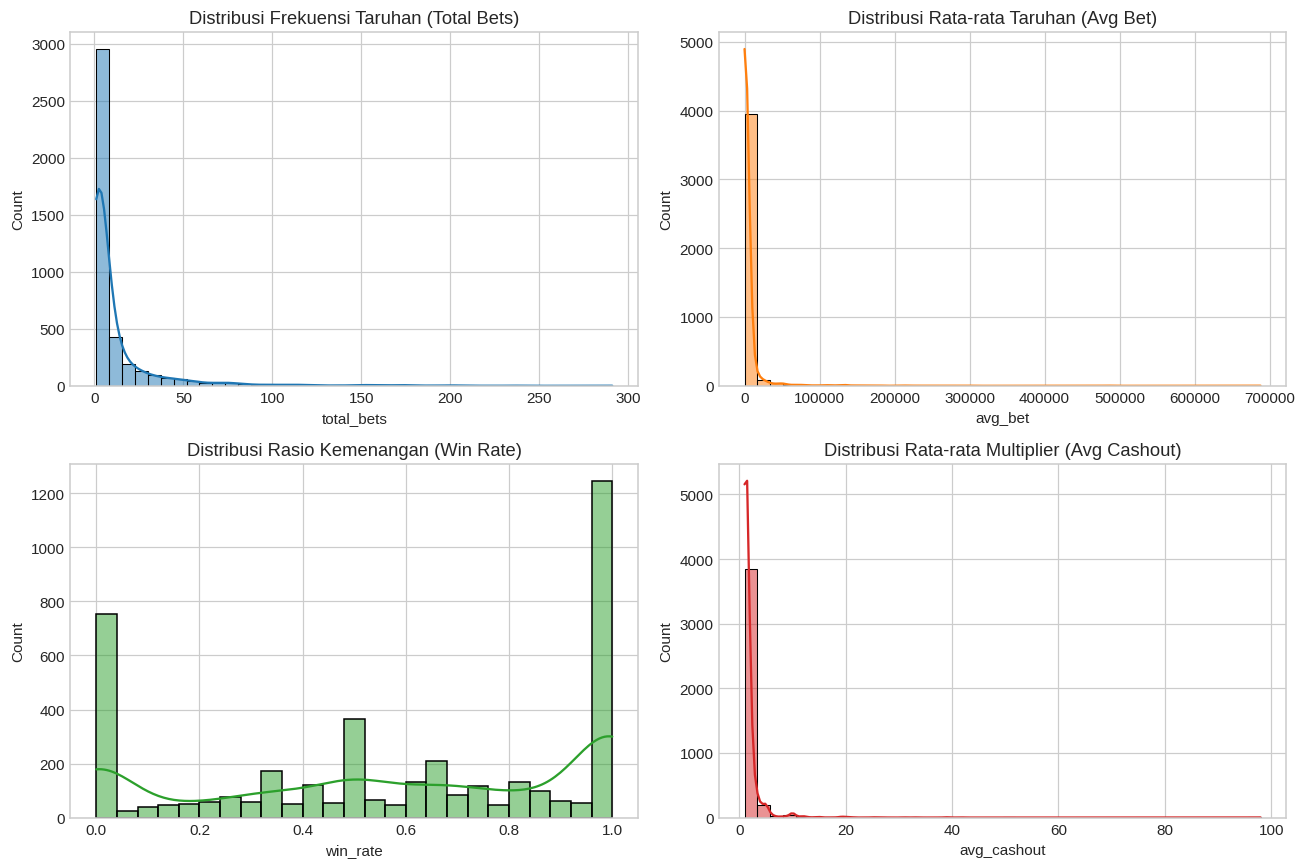

In [24]:
# Visualisasi distribusi metrik perilaku pemain
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(user_df['total_bets'], bins=40, kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Distribusi Frekuensi Taruhan (Total Bets)')

sns.histplot(user_df['avg_bet'], bins=40, kde=True, ax=axes[0, 1], color='#ff7f0e')
axes[0, 1].set_title('Distribusi Rata-rata Taruhan (Avg Bet)')

sns.histplot(user_df['win_rate'], bins=25, kde=True, ax=axes[1, 0], color='#2ca02c')
axes[1, 0].set_title('Distribusi Rasio Kemenangan (Win Rate)')

sns.histplot(user_df['avg_cashout'], bins=40, kde=True, ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Distribusi Rata-rata Multiplier (Avg Cashout)')

plt.tight_layout()
plt.show()

## 6. Transformasi & Penskalaan Fitur (Feature Scaling)
Distribusi `total_bets`, `avg_bet`, dan `avg_cashout` memperlihatkan pola kemiringan (*skewed*) tinggi karena terdapat pencilan ekstrem (misal pemain bertaruh jutaan bits atau multiplier ratusan kali). Untuk memastikan perhitungan jarak Euclidean pada K-Means bekerja objektif, variabel yang *skewed* ditransformasi dengan fungsi `np.log1p`, lalu distandarisasi menggunakan `StandardScaler`.

In [25]:
feature_cols = ['total_bets', 'avg_bet', 'win_rate', 'avg_cashout']
X_features = user_df[feature_cols].copy()

# Transformasi logaritmik untuk mereduksi skewness
for col in ['total_bets', 'avg_bet', 'avg_cashout']:
    X_features[col] = np.log1p(X_features[col])

# Standarisasi fitur ke skala seragam (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print('Ringkasan fitur setelah penskalaan standar:')
X_scaled_df.describe().round(3)

Ringkasan fitur setelah penskalaan standar:


,total_bets,avg_bet,win_rate,avg_cashout
count,4149.000,4149.000,4149.000,4149.000
mean,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-0.973,-1.721,-1.553,-0.680
25%,-0.973,-0.806,-0.824,-0.611
50%,-0.348,-0.024,0.119,-0.359
75%,0.565,0.673,1.122,0.245
max,3.522,3.140,1.122,9.805


## 7. Model Evaluation: Penentuan Jumlah Klaster Optimal (k)
Evaluasi clustering dijalankan dengan 3 parameter objektif:
1. **Elbow Method (Inertia / WCSS):** Menemukan titik kelengkungan siku peralihan laju penurunan variansi internal.
2. **Silhouette Score:** Mengukur tingkat kerapatan internal kelompok dan keterpisahan antar klaster (rentang -1 s.d. 1, makin tinggi makin baik).
3. **Davies-Bouldin Index (DBI):** Mengukur rasio sebaran data dalam klaster terhadap jarak antar pusat klaster (makin rendah makin baik).

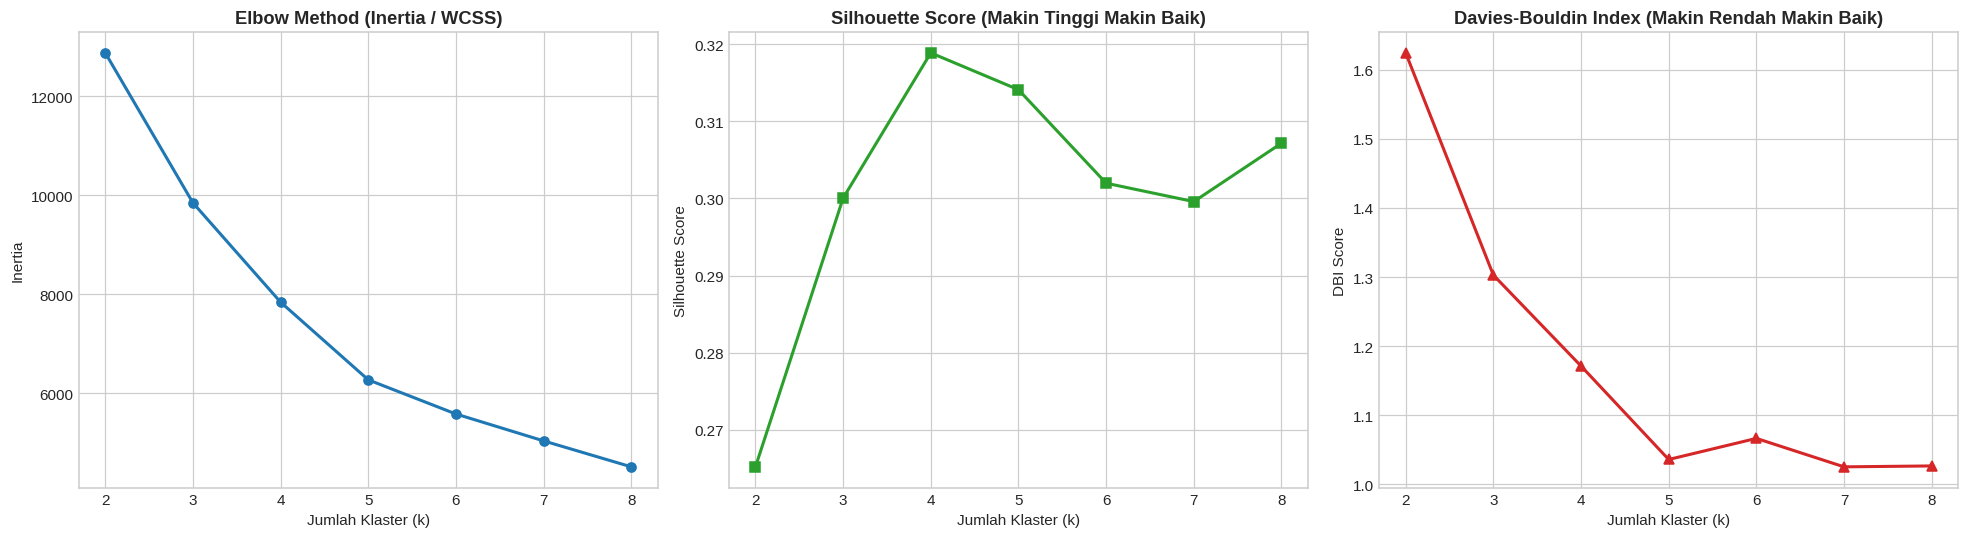

 k  Inertia (WCSS)  Silhouette Score  Davies-Bouldin Index
 2        12880.17            0.2652                1.6244
 3         9848.39            0.3001                1.3029
 4         7840.79            0.3189                1.1713
 5         6270.25            0.3141                1.0361
 6         5580.01            0.3020                1.0666
 7         5036.15            0.2996                1.0255
 8         4511.54            0.3072                1.0268


In [26]:
k_values = list(range(2, 9))
inertias = []
silhouette_scores = []
dbi_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot ketiga metrik evaluasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Elbow Method
axes[0].plot(k_values, inertias, marker='o', color='#1f77b4', linewidth=2)
axes[0].set_title('Elbow Method (Inertia / WCSS)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Klaster (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# 2. Silhouette Score
axes[1].plot(k_values, silhouette_scores, marker='s', color='#2ca02c', linewidth=2)
axes[1].set_title('Silhouette Score (Makin Tinggi Makin Baik)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Klaster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

# 3. Davies-Bouldin Index
axes[2].plot(k_values, dbi_scores, marker='^', color='#d62728', linewidth=2)
axes[2].set_title('Davies-Bouldin Index (Makin Rendah Makin Baik)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Jumlah Klaster (k)')
axes[2].set_ylabel('DBI Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Ringkasan tabel metrik evaluasi
eval_df = pd.DataFrame({
    'k': k_values,
    'Inertia (WCSS)': [round(v, 2) for v in inertias],
    'Silhouette Score': [round(v, 4) for v in silhouette_scores],
    'Davies-Bouldin Index': [round(v, 4) for v in dbi_scores]
})
print(eval_df.to_string(index=False))

## 8. Pelatihan Model Akhir K-Means (k = 4)
Berdasarkan analisis hasil evaluasi di atas:
- **Silhouette Score mencapai nilai puncak pada k = 4 (0.3189)**.
- Titik siku Elbow menunjukkan pelandaian konsisten pada rentang k = 3 hingga 5.
- Davies-Bouldin Index berada pada tingkat optimal (1.1713).
- Secara substansi praktis dan domain perjudian daring, 4 klaster menghasilkan segmentasi perilaku yang paling jelas dan tidak redundan.

In [27]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
user_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print('Distribusi Jumlah Anggota per Klaster:')
print(user_df['Cluster'].value_counts().sort_index())

Distribusi Jumlah Anggota per Klaster:
Cluster
0    1067
1    1732
2     354
3     996
Name: count, dtype: int64


## 9. Profiling & Karakterisasi Klaster Perilaku
Menganalisis rata-rata nilai variabel pada skala riil untuk memahami ciri psikologis dan profil risiko masing-masing kelompok pemain.

In [28]:
profile_table = user_df.groupby('Cluster').agg(
    Jumlah_Pemain=('Username', 'count'),
    Total_Taruhan=('total_bets', 'mean'),
    Rata_Taruhan=('avg_bet', 'mean'),
    Win_Rate=('win_rate', 'mean'),
    Rata_Multiplier=('avg_cashout', 'mean'),
    Total_Profit=('total_profit', 'mean')
).round(2)

cluster_descriptions = {
    0: 'Active Grinders (Taruhan Sering, Win Rate Stabil ~63%, Profit Positif)',
    1: 'Casual Conservative Winners (Frekuensi Rendah, Win Rate ~89%, Multiplier Rendah)',
    2: 'High-Risk Seekers (Multiplier Ekstrem ~7.1x, Win Rate Rendah ~30%, Rugi Bersih)',
    3: 'Unlucky Casuals (Frekuensi Rendah, Win Rate Sangat Rendah ~9%, Cepat Rugi)'
}
profile_table['Label_Profil'] = profile_table.index.map(cluster_descriptions)
profile_table

,Jumlah_Pemain,Total_Taruhan,Rata_Taruhan,Win_Rate,Rata_Multiplier,Total_Profit,Label_Profil
Cluster,,,,,,,
0,1067,33.24,2838.22,0.63,1.59,4963.32,"Active Grinders (Taruhan Sering, Win Rate Stab..."
1,1732,2.62,6389.10,0.89,1.43,4022.74,"Casual Conservative Winners (Frekuensi Rendah,..."
2,354,21.49,2083.20,0.30,7.13,-2335.37,"High-Risk Seekers (Multiplier Ekstrem ~7.1x, W..."
3,996,2.40,5292.29,0.09,1.12,-9186.16,"Unlucky Casuals (Frekuensi Rendah, Win Rate Sa..."


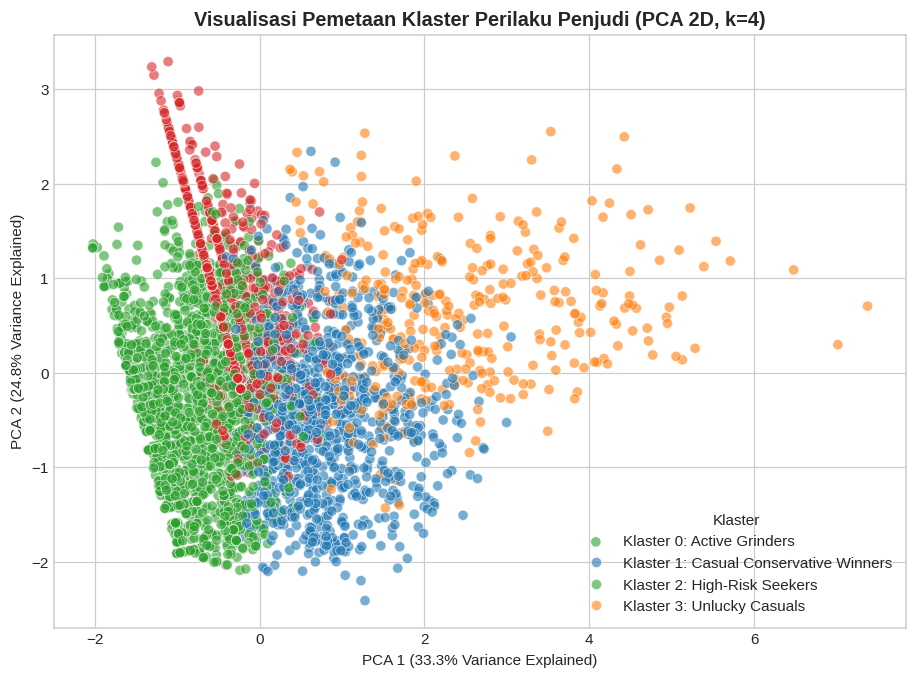

In [29]:
# Visualisasi Reduksi Dimensi 2D Menggunakan PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
user_df['PCA1'] = coords[:, 0]
user_df['PCA2'] = coords[:, 1]

palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=user_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette=palette,
    alpha=0.6,
    s=45
)
plt.title(f'Visualisasi Pemetaan Klaster Perilaku Penjudi (PCA 2D, k={optimal_k})', fontsize=13, fontweight='bold')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance Explained)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance Explained)')
plt.legend(title='Klaster', labels=[f'Klaster {i}: {cluster_descriptions[i].split(" (")[0]}' for i in range(optimal_k)])
plt.grid(True)
plt.show()

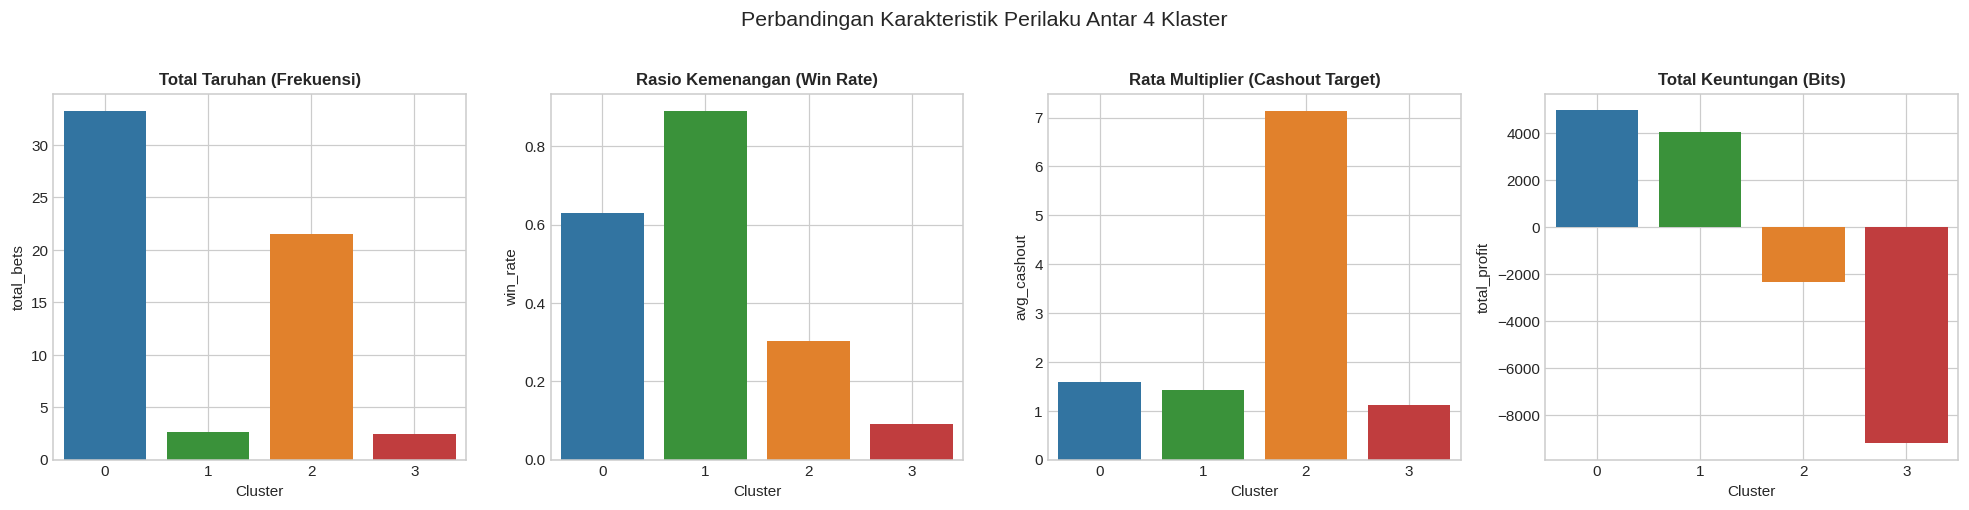

In [30]:
# Visualisasi perbandingan metrik perilaku antar klaster
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
metrics = ['total_bets', 'win_rate', 'avg_cashout', 'total_profit']
titles = ['Total Taruhan (Frekuensi)', 'Rasio Kemenangan (Win Rate)', 'Rata Multiplier (Cashout Target)', 'Total Keuntungan (Bits)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    sns.barplot(data=user_df, x='Cluster', y=metric, ax=axes[idx], palette=palette, ci=None)
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].grid(True)

plt.suptitle('Perbandingan Karakteristik Perilaku Antar 4 Klaster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Kesimpulan & Batasan Evaluasi (CPMK2)

### Ringkasan Hasil Evaluasi:
1. **Jumlah Klaster Optimal:** Konfigurasi $k = 4$ terbukti sebagai pilihan terbaik berdasarkan metrik kuantitatif (Silhouette Score tertinggi sebesar 0.3189 dan DBI 1.1713).
2. **Taksonomi Segmen Perilaku yang Ditemukan:**
   - **Klaster 0 (Active Grinders):** Pemain intensif (~33 taruhan) dengan strategi terukur, win rate tinggi (63%), dan profit positif konsisten.
   - **Klaster 1 (Casual Conservative Winners):** Pemain disiplin dengan frekuensi rendah yang cepat mengambil keuntungan pada multiplier aman (~1.43x) dengan win rate 89%.
   - **Klaster 2 (High-Risk Seekers):** Pemain berisiko tinggi yang mengejar multiplier fantastis (rata-rata 7.13x), menghasilkan tingkat kegagalan tinggi dan kerugian akumulatif terbesar.
   - **Klaster 3 (Unlucky Casuals):** Pemain baru yang langsung menelan kekalahan beruntun (win rate hanya 9%).

### Batasan Pengerjaan:
Sesuai ketentuan penugasan CPMK2, pengerjaan dihentikan tepat pada tahap **Model Evaluation & Interpretation**, tanpa melanjutkan ke tahap deployment aplikasi atau implementasi antarmuka pengguna.